# 1.4 Preprocessed Data — Feature Engineering

Transform the preprocessed train data into model-ready features.

**Steps:**
1. Load preprocessed train data
2. Encode categorical variables
3. Create new features
4. Scale numerical features
5. Final feature set validation
6. Save engineered features + configuration

> The held-out test split is **not** engineered here; notebook 1_6 applies the saved configuration (`artifacts/preprocessing/data_features.json` + `data_scaler.json`) to it.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1.4.1 Load Preprocessed Data (Train)


In [2]:
df_train = pd.read_csv('../data/data_preprocessed_train.csv')

print(f'Loaded {df_train.shape[0]} train rows and {df_train.shape[1]} columns')
df_train.head()


Loaded 67 train rows and 8 columns


,price,sqft,bedrooms,bathrooms,location,year_built,condition,house_age
0,730000.0,2620,3,2.5,Downtown,1994,Excellent,32
1,312000.0,1680,2,1.5,Rural,1959,Fair,67
2,520000.0,2050,3,2.0,Urban,1990,Good,36
3,615000.0,2230,3,2.0,Downtown,1986,Good,40
4,398000.0,1680,2,2.0,Suburb,1968,Fair,58


## 1.4.2 Encode Categorical Variables

In [3]:
LOCATION_CATEGORIES = ['Downtown', 'Mountain', 'Rural', 'Suburb', 'Urban', 'Waterfront']

df_train_encoded = df_train.copy()
df_train_encoded['location'] = pd.Categorical(df_train['location'], categories=LOCATION_CATEGORIES)

df_train_encoded = pd.get_dummies(df_train_encoded, columns=['location'], prefix='loc', drop_first=False)

location_dummies = [c for c in df_train_encoded.columns if c.startswith('loc_')]

print(f'After one-hot encoding location: {df_train_encoded.shape[1]} columns')
print(f'Location dummies: {location_dummies}')


After one-hot encoding location: 13 columns
Location dummies: ['loc_Downtown', 'loc_Mountain', 'loc_Rural', 'loc_Suburb', 'loc_Urban', 'loc_Waterfront']


In [4]:
condition_order = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}
df_train_encoded['condition_encoded'] = df_train_encoded['condition'].map(condition_order)

print('Condition encoding:')
for k, v in condition_order.items():
    print(f'  {k} -> {v}')

df_train_encoded.drop(columns=['condition'], inplace=True)
print(f'\nFinal train columns: {df_train_encoded.columns.tolist()}')


Condition encoding:
  Poor -> 0
  Fair -> 1
  Good -> 2
  Excellent -> 3

Final train columns: ['price', 'sqft', 'bedrooms', 'bathrooms', 'year_built', 'house_age', 'loc_Downtown', 'loc_Mountain', 'loc_Rural', 'loc_Suburb', 'loc_Urban', 'loc_Waterfront', 'condition_encoded']


## 1.4.3 Create New Features

In [5]:
df_train_encoded['total_rooms'] = df_train_encoded['bedrooms'] + df_train_encoded['bathrooms']
df_train_encoded['bath_bed_ratio'] = df_train_encoded['bathrooms'] / df_train_encoded['bedrooms'].replace(0, 1)
df_train_encoded['is_luxury'] = ((df_train_encoded['condition_encoded'] >= 3) & (df_train_encoded['sqft'] >= 2500)).astype(int)
df_train_encoded['is_new'] = (df_train_encoded['house_age'] <= 15).astype(int)
df_train_encoded['sqft_per_bedroom'] = df_train_encoded['sqft'] / df_train_encoded['bedrooms'].replace(0, 1)
df_train_encoded['log_price'] = np.log1p(df_train_encoded['price'])

print('Created 6 new features (train)')
df_train_encoded[['price', 'log_price', 'total_rooms', 'bath_bed_ratio', 'is_luxury', 'is_new', 'sqft_per_bedroom']].head(10)


Created 6 new features (train)


,price,log_price,total_rooms,bath_bed_ratio,is_luxury,is_new,sqft_per_bedroom
0,730000.0,13.500801,5.5,0.833333,1,0,873.333333
1,312000.0,12.650762,3.5,0.750000,0,0,840.000000
2,520000.0,13.161586,5.0,0.666667,0,0,683.333333
3,615000.0,13.329379,5.0,0.666667,0,0,743.333333
4,398000.0,12.894210,4.0,1.000000,0,0,840.000000
5,537000.0,13.193755,5.0,0.666667,0,0,683.333333
6,1250000.0,14.038655,7.5,0.875000,1,0,812.500000
7,527000.0,13.174958,5.0,0.666667,0,0,670.000000
8,1220000.0,14.014362,7.5,0.875000,1,0,805.000000
9,401000.0,12.901719,3.5,0.750000,0,0,871.000000


## 1.4.4 Scale Numerical Features (scaler fitted on train)


In [6]:
features_to_scale = ['sqft', 'bedrooms', 'bathrooms', 'house_age',
                     'total_rooms', 'bath_bed_ratio', 'sqft_per_bedroom']

scaler = StandardScaler()
df_train_scaled = df_train_encoded.copy()
df_train_scaled[features_to_scale] = scaler.fit_transform(df_train_encoded[features_to_scale])

print('Scaler fitted on TRAIN split only (mean/std saved for 1_6).')
print('Scaled features statistics (train):')
df_train_scaled[features_to_scale].describe().round(2)


Scaler fitted on TRAIN split only (mean/std saved for 1_6).
Scaled features statistics (train):


,sqft,bedrooms,bathrooms,house_age,total_rooms,bath_bed_ratio,sqft_per_bedroom
count,67.00,67.00,67.00,67.00,67.00,67.00,67.00
mean,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00
std,1.01,1.01,1.01,1.01,1.01,1.01,1.01
min,-1.30,-1.11,-1.42,-1.83,-1.29,-1.94,-1.97
25%,-0.79,-1.11,-0.85,-0.65,-0.99,-0.64,-0.77
50%,-0.28,0.09,-0.27,-0.08,-0.09,0.01,-0.07
75%,0.55,0.09,0.31,0.87,0.21,0.67,0.88
max,2.45,2.49,2.62,1.82,2.60,1.97,2.63


## 1.4.5 Feature Importance Preview

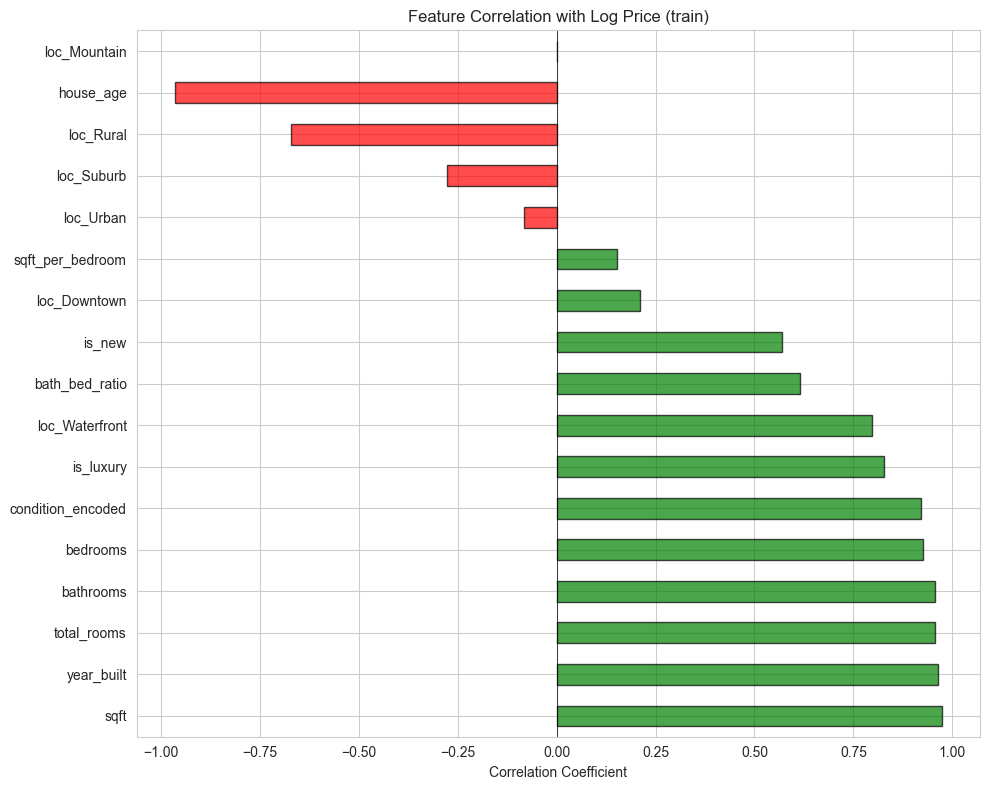


Correlation with log_price:
sqft                 0.973
year_built           0.964
total_rooms          0.957
bathrooms            0.957
bedrooms             0.925
condition_encoded    0.920
is_luxury            0.828
loc_Waterfront       0.796
bath_bed_ratio       0.615
is_new               0.570
loc_Downtown         0.210
sqft_per_bedroom     0.152
loc_Urban           -0.081
loc_Suburb          -0.277
loc_Rural           -0.671
house_age           -0.964
loc_Mountain           NaN
Name: log_price, dtype: float64


In [7]:
feature_cols = [c for c in df_train_scaled.columns if c not in ['price', 'log_price']]
corr_with_target = df_train_scaled[feature_cols + ['log_price']].corr()['log_price'].drop('log_price').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in corr_with_target.values]
corr_with_target.plot(kind='barh', ax=ax, color=colors, edgecolor='black', alpha=0.7)
ax.set_title('Feature Correlation with Log Price (train)')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('\nCorrelation with log_price:')
print(corr_with_target.round(3))

## 1.4.6 Final Feature Set

In [8]:
FEATURE_COLS = [c for c in df_train_scaled.columns
                if c not in ['price', 'log_price']]

print(f'Final feature count: {len(FEATURE_COLS)}')
print(f'\nFeatures:')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')

print(f'\nTarget: price (log_price for training)')
print(f'\nTrain feature matrix shape: {df_train_scaled[FEATURE_COLS].shape}')


Final feature count: 17

Features:
   1. sqft
   2. bedrooms
   3. bathrooms
   4. year_built
   5. house_age
   6. loc_Downtown
   7. loc_Mountain
   8. loc_Rural
   9. loc_Suburb
  10. loc_Urban
  11. loc_Waterfront
  12. condition_encoded
  13. total_rooms
  14. bath_bed_ratio
  15. is_luxury
  16. is_new
  17. sqft_per_bedroom

Target: price (log_price for training)

Train feature matrix shape: (67, 17)


## 1.4.7 Save Feature-Ready Data + Configuration


In [9]:
data_dir = '../data'
artifacts_dir = '../artifacts'

train_output_path = os.path.join(data_dir, 'data_feature_train.csv')
df_train_scaled.to_csv(train_output_path, index=False)
print(f'Saved train feature dataset to {train_output_path}')
print(f'Train shape: {df_train_scaled.shape}')

preprocessing_dir = os.path.join(artifacts_dir, 'preprocessing')
os.makedirs(preprocessing_dir, exist_ok=True)

feature_list_path = os.path.join(preprocessing_dir, 'data_features.json')
with open(feature_list_path, 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)
print(f'Saved feature list to {feature_list_path}')

scaler_params = {
    'features': features_to_scale,
    'mean': dict(zip(features_to_scale, scaler.mean_)),
    'std': dict(zip(features_to_scale, scaler.scale_))
}
scaler_path = os.path.join(preprocessing_dir, 'data_scaler.json')
with open(scaler_path, 'w') as f:
    json.dump(scaler_params, f, indent=2)
print(f'Saved scaler parameters to {scaler_path}')


Saved train feature dataset to ../data\data_feature_train.csv
Train shape: (67, 19)
Saved feature list to ../artifacts\preprocessing\data_features.json
Saved scaler parameters to ../artifacts\preprocessing\data_scaler.json
